# FYP Notebook 3 — Threshold Optimisation & Model Interpretability
**Student:** Angal Hemanth Reddy | A00088732 · **Supervisor:** Dr. Sayed Pouria Talebi

Completes two objectives outstanding after Notebook 2:

**A. Per-label threshold optimisation.** Notebook 2 evaluated at a fixed 0.5 cut-off. ROC AUC stayed
above 0.986 for every label while F1 fell to 0.42 on rare labels — a threshold artefact, not a
ranking failure. This notebook tunes a threshold per label on the validation set and re-scores.

**B. Interpretability.** The project proposal listed model explainability as an objective. This
notebook extracts attention-based token attributions and inspects what drives predictions.

### ▶ Setup
`+ Add Input` → **jigsaw-toxic-comment-classification-challenge** · **GPU** · **Internet ON** · Run All (~40–60 min)

> This notebook retrains BERT briefly so it is self-contained. If Notebook 2 is still in session,
> skip Section 2 and reuse its `model`, `tokenizer`, `val_df`, `te_df`.


## 1 · Setup

In [1]:
import os, glob, gc, json, inspect, warnings, numpy as np, pandas as pd
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt, seaborn as sns
sns.set_style("whitegrid")
import torch, torch.nn as nn
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, roc_auc_score, precision_recall_curve, classification_report

LABELS = ["toxic","severe_toxic","obscene","threat","insult","identity_hate"]
TEXT = "comment_text"; NUM_LABELS = len(LABELS)
MAX_LEN = 192; BATCH = 16; EPOCHS = 2

print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available(): print("GPU:", torch.cuda.get_device_name(0))


CUDA: True
GPU: Tesla T4


## 2 · Load data and fine-tune BERT

In [2]:
p = glob.glob("/kaggle/input/**/train.csv", recursive=True)
if not p: raise FileNotFoundError("Add the jigsaw dataset via '+ Add Input'.")
df = pd.read_csv(p[0])
df = df[df[TEXT].notna() & (df[TEXT].astype(str).str.strip().str.len() > 1)]
df = df.drop_duplicates(subset=[TEXT]).reset_index(drop=True)

strat = (df[LABELS].values.sum(axis=1) > 0).astype(int)
tr_df, tmp = train_test_split(df, test_size=0.30, random_state=42, stratify=strat)
s2 = (tmp[LABELS].values.sum(axis=1) > 0).astype(int)
va_df, te_df = train_test_split(tmp, test_size=0.50, random_state=42, stratify=s2)
tr_df, va_df, te_df = [d.reset_index(drop=True) for d in (tr_df, va_df, te_df)]
Y_val, Y_test = va_df[LABELS].values.astype(int), te_df[LABELS].values.astype(int)
print(f"Train {len(tr_df):,} | Val {len(va_df):,} | Test {len(te_df):,}")


Train 111,699 | Val 23,936 | Test 23,936


In [3]:
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer)

MODEL_NAME = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class MLDataset(Dataset):
    def __init__(s, t, l, tok, ml):
        s.t = list(t); s.y = np.asarray(l, dtype=np.float32); s.tok = tok; s.ml = ml
    def __len__(s): return len(s.t)
    def __getitem__(s, i):
        e = s.tok(str(s.t[i]), truncation=True, padding="max_length",
                  max_length=s.ml, return_tensors="pt")
        it = {k: v.squeeze(0) for k, v in e.items()}
        it["labels"] = torch.tensor(s.y[i], dtype=torch.float)
        return it

pos = tr_df[LABELS].values.sum(axis=0); neg = len(tr_df) - pos
pos_w = torch.tensor(np.clip(neg / np.maximum(pos, 1), 1, 50), dtype=torch.float)

class MLTrainer(Trainer):
    def __init__(s, pos_weight=None, **kw): super().__init__(**kw); s.pw = pos_weight
    def compute_loss(s, model, inputs, return_outputs=False, **kwargs):
        y = inputs.pop("labels"); o = model(**inputs); lg = o.logits
        w = s.pw.to(lg.device) if s.pw is not None else None
        loss = nn.BCEWithLogitsLoss(pos_weight=w)(lg, y.float())
        return (loss, o) if return_outputs else loss

_TA = set(inspect.signature(TrainingArguments.__init__).parameters)
_EK = "eval_strategy" if "eval_strategy" in _TA else "evaluation_strategy"
kw = dict(output_dir="./b3", num_train_epochs=EPOCHS, learning_rate=2e-5,
          per_device_train_batch_size=BATCH, per_device_eval_batch_size=BATCH*2,
          weight_decay=0.01, save_strategy="no", logging_steps=200,
          fp16=torch.cuda.is_available(), report_to="none", seed=42)
kw[_EK] = "no"

# attn_implementation="eager" is REQUIRED: the default SDPA backend does not
# return attention weights, so output_attentions=True in Section 4 would fail.
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_LABELS,
    problem_type="multi_label_classification",
    attn_implementation="eager")
trainer = MLTrainer(pos_weight=pos_w, model=model, args=TrainingArguments(**kw),
                    train_dataset=MLDataset(tr_df[TEXT], tr_df[LABELS].values, tokenizer, MAX_LEN))
trainer.train()
print("Training complete.")


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
200,0.573864
400,0.348141
600,0.330148
800,0.267710
1000,0.293296
1200,0.260739
1400,0.239802
1600,0.231604
1800,0.217236
2000,0.273409


Training complete.


In [4]:
def sigmoid(x): return 1/(1+np.exp(-x))
val_prob  = sigmoid(trainer.predict(MLDataset(va_df[TEXT], va_df[LABELS].values, tokenizer, MAX_LEN)).predictions)
test_prob = sigmoid(trainer.predict(MLDataset(te_df[TEXT], te_df[LABELS].values, tokenizer, MAX_LEN)).predictions)
print("Probabilities computed:", val_prob.shape, test_prob.shape)


Probabilities computed: (23936, 6) (23936, 6)


## 3 · Part A — Per-label threshold optimisation
Thresholds are selected on the **validation** set only, then applied unchanged to the test set.
Tuning on test would leak information and inflate the reported score.

In [5]:
best_thr = {}
for i, L in enumerate(LABELS):
    grid = np.arange(0.05, 0.96, 0.01)
    f1s = [f1_score(Y_val[:, i], (val_prob[:, i] >= t).astype(int), zero_division=0) for t in grid]
    best_thr[L] = float(grid[int(np.argmax(f1s))])
    print(f"{L:15s} best threshold={best_thr[L]:.2f}  val F1={max(f1s):.4f}")

json.dump(best_thr, open("/kaggle/working/best_thresholds.json","w"), indent=2)


toxic           best threshold=0.94  val F1=0.8330
severe_toxic    best threshold=0.94  val F1=0.5090
obscene         best threshold=0.95  val F1=0.8357
threat          best threshold=0.92  val F1=0.5965
insult          best threshold=0.94  val F1=0.7735
identity_hate   best threshold=0.92  val F1=0.6144


In [6]:
# Apply tuned thresholds to the TEST set
pred_050 = (test_prob >= 0.5).astype(int)
pred_tuned = np.zeros_like(pred_050)
for i, L in enumerate(LABELS):
    pred_tuned[:, i] = (test_prob[:, i] >= best_thr[L]).astype(int)

rows = []
for i, L in enumerate(LABELS):
    rows.append({
        "label": L, "support": int(Y_test[:, i].sum()),
        "AUC": roc_auc_score(Y_test[:, i], test_prob[:, i]),
        "F1 @0.5": f1_score(Y_test[:, i], pred_050[:, i], zero_division=0),
        "threshold": best_thr[L],
        "F1 tuned": f1_score(Y_test[:, i], pred_tuned[:, i], zero_division=0),
    })
per = pd.DataFrame(rows)
per["gain"] = (per["F1 tuned"] - per["F1 @0.5"]).round(4)
print(per.round(4).to_string(index=False))

print()
for name, P in [("0.5 fixed", pred_050), ("tuned", pred_tuned)]:
    print(f"{name:10s} micro F1={f1_score(Y_test,P,average='micro',zero_division=0):.4f} "
          f"macro F1={f1_score(Y_test,P,average='macro',zero_division=0):.4f}")
per.to_csv("/kaggle/working/threshold_results.csv", index=False)


        label  support    AUC  F1 @0.5  threshold  F1 tuned   gain
        toxic     2296 0.9868   0.7972       0.94    0.8320 0.0347
 severe_toxic      233 0.9923   0.4226       0.94    0.5290 0.1064
      obscene     1271 0.9934   0.7788       0.95    0.8491 0.0703
       threat       84 0.9829   0.5500       0.92    0.5591 0.0091
       insult     1204 0.9895   0.7141       0.94    0.7837 0.0696
identity_hate      208 0.9891   0.5038       0.92    0.6065 0.1027

0.5 fixed  micro F1=0.7260 macro F1=0.6277
tuned      micro F1=0.7921 macro F1=0.6932


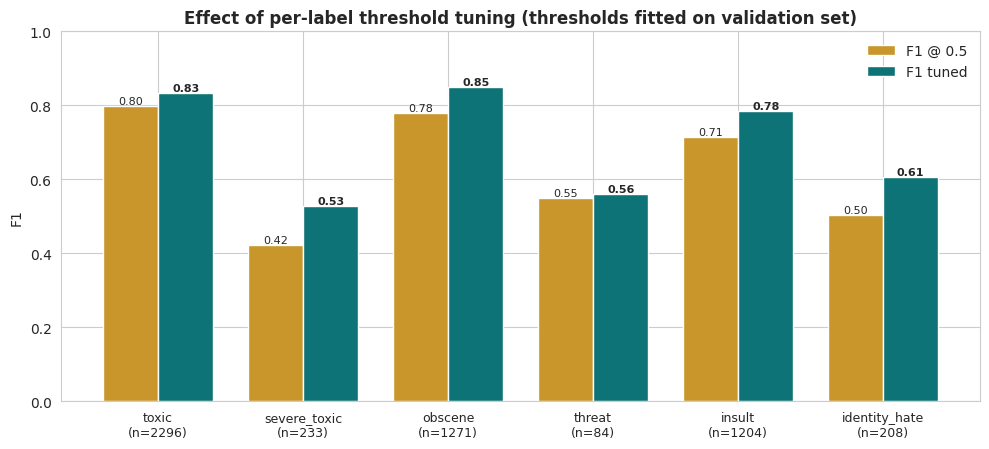

In [7]:
fig, ax = plt.subplots(figsize=(10, 4.6))
x = np.arange(len(LABELS)); w = 0.38
ax.bar(x-w/2, per["F1 @0.5"], w, label="F1 @ 0.5", color="#C9962B")
ax.bar(x+w/2, per["F1 tuned"], w, label="F1 tuned", color="#0D7377")
ax.set_xticks(x); ax.set_xticklabels([f"{l}\n(n={s})" for l,s in zip(per['label'],per['support'])], fontsize=9)
ax.set_ylabel("F1"); ax.set_ylim(0,1.0); ax.legend(frameon=False)
ax.set_title("Effect of per-label threshold tuning (thresholds fitted on validation set)",
             fontweight="bold")
for xi,(a,b_) in enumerate(zip(per["F1 @0.5"], per["F1 tuned"])):
    ax.annotate(f"{a:.2f}", (xi-w/2,a), ha="center", va="bottom", fontsize=8)
    ax.annotate(f"{b_:.2f}", (xi+w/2,b_), ha="center", va="bottom", fontsize=8, fontweight="bold")
plt.tight_layout(); plt.savefig("/kaggle/working/fig_threshold_tuning.png", dpi=200); plt.show()


## 4 · Part B — Interpretability via attention attribution
Token-level attributions are derived from the final-layer attention directed at the `[CLS]`
position, averaged over heads. This indicates which tokens the pooled representation drew from
when forming its prediction.

> **Interpretive caution:** attention weights show where the model looked, not a causal account of
> why it decided. This is a widely used but contested proxy and is reported as indicative only.

In [8]:
model.eval(); device = next(model.parameters()).device

def attributions(text, top_k=12):
    enc = tokenizer(str(text), truncation=True, max_length=MAX_LEN, return_tensors="pt").to(device)
    with torch.no_grad():
        out = model(**enc, output_attentions=True)
    if not out.attentions:
        raise RuntimeError(
            "No attention weights returned. Reload the model with "
            "attn_implementation='eager' (see Section 2) and re-run.")
    probs = torch.sigmoid(out.logits)[0].cpu().numpy()
    att = out.attentions[-1][0].mean(0)[0]           # last layer, mean over heads, CLS row
    toks = tokenizer.convert_ids_to_tokens(enc["input_ids"][0])
    scores = att.cpu().numpy()
    keep = [(t, s) for t, s in zip(toks, scores) if t not in ("[CLS]","[SEP]","[PAD]")]
    keep.sort(key=lambda z: -z[1])
    return probs, keep[:top_k]

# Inspect the most confidently toxic test comments
idx = np.argsort(-test_prob[:, 0])[:3]
for j in idx:
    txt = te_df[TEXT].iloc[j]
    probs, toks = attributions(txt)
    print("="*72)
    print("COMMENT:", str(txt)[:220].replace("\n"," "))
    print("TRUE :", [L for i,L in enumerate(LABELS) if Y_test[j,i]==1] or ["(none)"])
    print("PRED :", {L: round(float(p),3) for L,p in zip(LABELS,probs) if p>=best_thr[L]} or "(none above threshold)")
    print("TOP ATTENDED TOKENS:", [t for t,_ in toks])
    print()


COMMENT: Hey   What is the deal? How about you show some respect. You piece of shit. I will break you knees if you try any more funny business you queer.
TRUE : ['toxic']
PRED : {'toxic': 0.999, 'obscene': 0.994, 'insult': 0.998, 'identity_hate': 0.978}
TOP ATTENDED TOKENS: ['queer', 'break', 'will', 'you', 'piece', 'shit', 'you', 'i', '.', 'of', 'you', 'knees']

COMMENT: Just To Let You Know. You have no life. I hate you.I hate you.I hate you.I hate you.I hate you.I hate you.I hate you.I hate you.I hate you.I hate you.I hate you.I hate you.I hate you.I hate you.I hate you.I hate you.I ha
TRUE : ['toxic']
PRED : {'toxic': 0.999, 'obscene': 0.994, 'insult': 0.996}
TOP ATTENDED TOKENS: ['.', '.', 'hate', 'just', 'hate', 'you', 'you', 'hate', 'you', 'hate', 'you', 'you']

COMMENT: Response to your Personal Appeal from Jimmy Wales   Response to your Personal Appeal from Jimmy Wales:  Go fuck yourself. This place is a big shithole and you're the biggest shithead of them all. Die in a fire y

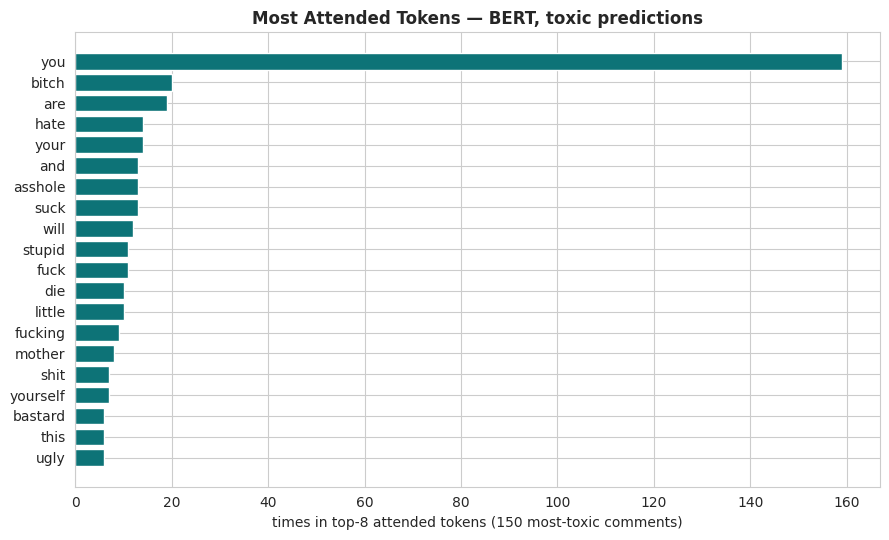

Note: profanity is expected to dominate. Presence of identity terms would indicate
possible bias and should be discussed in the report's limitations.


In [9]:
# Aggregate: which tokens are most attended across many toxic predictions?
from collections import Counter
cnt = Counter()
sample_idx = np.argsort(-test_prob[:,0])[:150]
for j in sample_idx:
    _, toks = attributions(te_df[TEXT].iloc[j], top_k=8)
    for t,_ in toks:
        if t.isalpha() and len(t) > 2: cnt[t] += 1

top = cnt.most_common(20)
fig, ax = plt.subplots(figsize=(9,5.5))
ax.barh([t for t,_ in top][::-1], [c for _,c in top][::-1], color="#0D7377")
ax.set_xlabel("times in top-8 attended tokens (150 most-toxic comments)")
ax.set_title("Most Attended Tokens — BERT, toxic predictions", fontweight="bold")
plt.tight_layout(); plt.savefig("/kaggle/working/fig_attention_tokens.png", dpi=200); plt.show()
print("Note: profanity is expected to dominate. Presence of identity terms would indicate")
print("possible bias and should be discussed in the report's limitations.")


## 6 · Additional evaluation figures
Generates ROC curves, precision-recall curves, per-label confusion matrices and predicted-probability
distributions. All saved to `/kaggle/working/` as PNG for inclusion in the report.

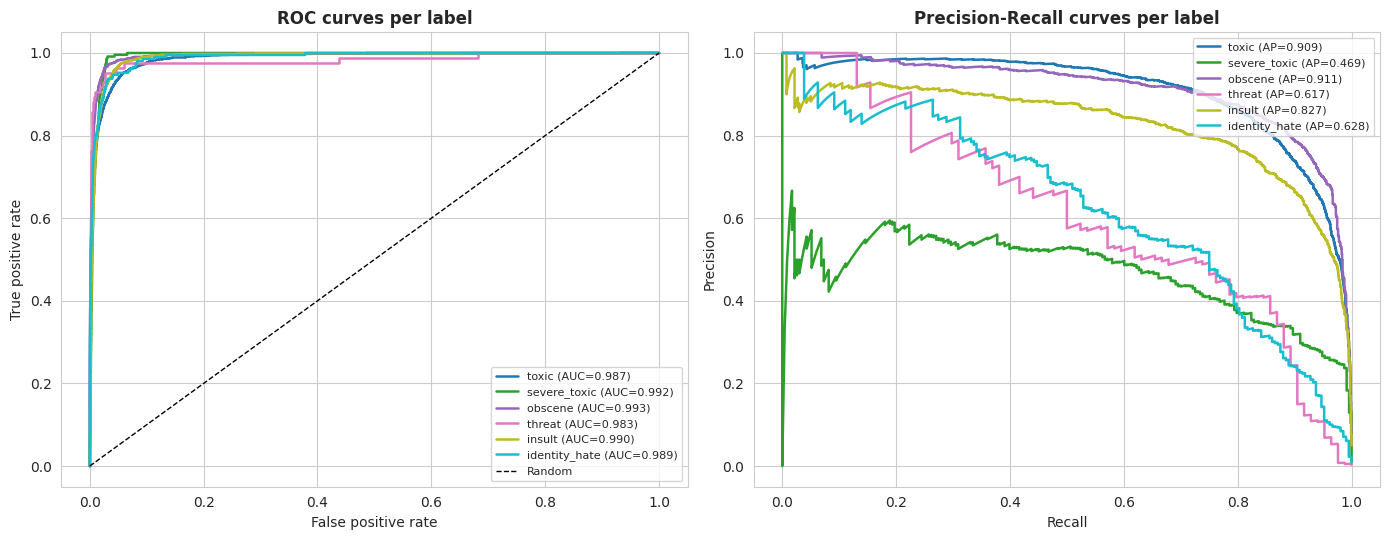

Note: PR curves fall away on rare labels even where ROC AUC is high — PR is the more
informative view under severe imbalance because it ignores true negatives.


In [10]:
from sklearn.metrics import roc_curve, precision_recall_curve, average_precision_score

fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))
colors = plt.cm.tab10(np.linspace(0, 1, len(LABELS)))

for i, (Lb, c) in enumerate(zip(LABELS, colors)):
    fpr, tpr, _ = roc_curve(Y_test[:, i], test_prob[:, i])
    a = roc_auc_score(Y_test[:, i], test_prob[:, i])
    ax[0].plot(fpr, tpr, color=c, lw=1.8, label=f"{Lb} (AUC={a:.3f})")

    pr, rc, _ = precision_recall_curve(Y_test[:, i], test_prob[:, i])
    ap = average_precision_score(Y_test[:, i], test_prob[:, i])
    ax[1].plot(rc, pr, color=c, lw=1.8, label=f"{Lb} (AP={ap:.3f})")

ax[0].plot([0, 1], [0, 1], "k--", lw=1, label="Random")
ax[0].set_xlabel("False positive rate"); ax[0].set_ylabel("True positive rate")
ax[0].set_title("ROC curves per label", fontweight="bold"); ax[0].legend(fontsize=8, loc="lower right")

ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision")
ax[1].set_title("Precision-Recall curves per label", fontweight="bold")
ax[1].legend(fontsize=8, loc="upper right")

plt.tight_layout(); plt.savefig("/kaggle/working/fig_roc_pr_curves.png", dpi=200); plt.show()
print("Note: PR curves fall away on rare labels even where ROC AUC is high — PR is the more")
print("informative view under severe imbalance because it ignores true negatives.")


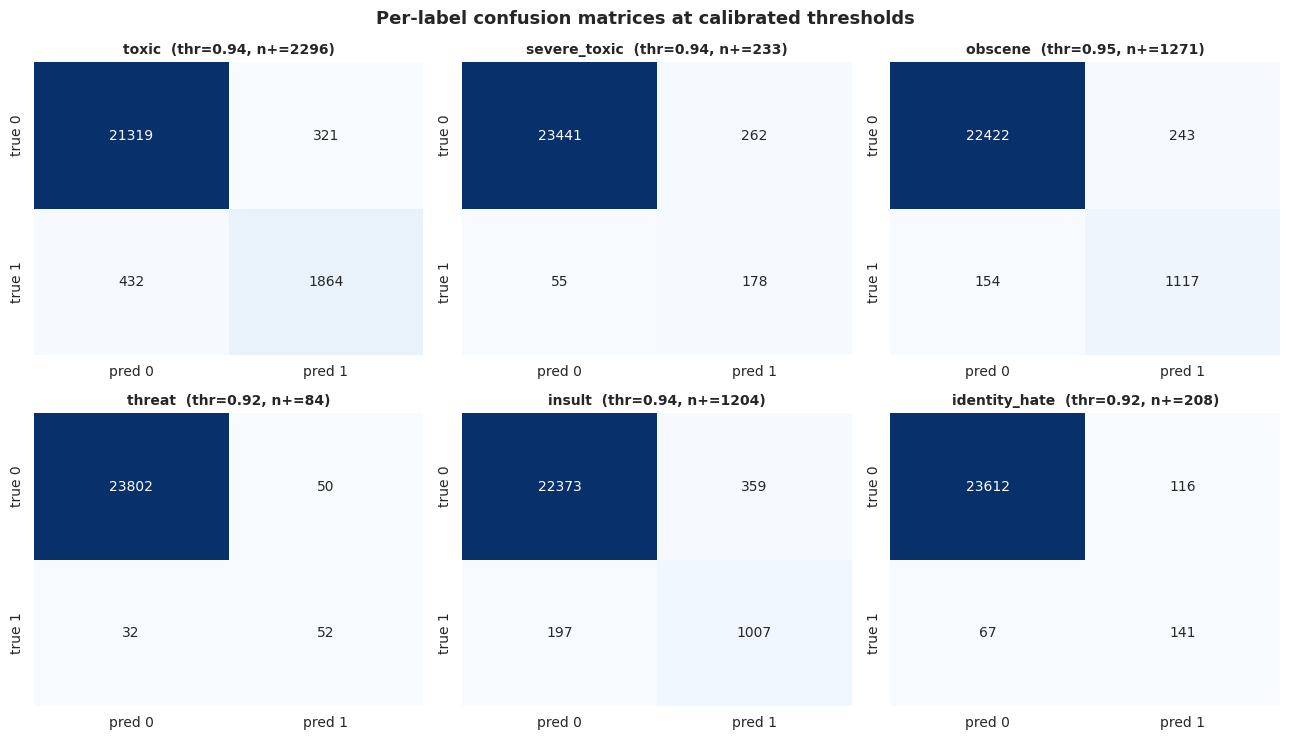

In [11]:
from sklearn.metrics import confusion_matrix

# Per-label binary confusion matrices at the CALIBRATED thresholds
fig, axes = plt.subplots(2, 3, figsize=(13, 7.5))
for i, (Lb, ax_) in enumerate(zip(LABELS, axes.ravel())):
    pred_i = (test_prob[:, i] >= best_thr[Lb]).astype(int)
    cm = confusion_matrix(Y_test[:, i], pred_i)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax_,
                xticklabels=["pred 0", "pred 1"], yticklabels=["true 0", "true 1"])
    ax_.set_title(f"{Lb}  (thr={best_thr[Lb]:.2f}, n+={int(Y_test[:,i].sum())})",
                  fontweight="bold", fontsize=10)
plt.suptitle("Per-label confusion matrices at calibrated thresholds",
             fontweight="bold", fontsize=13)
plt.tight_layout(); plt.savefig("/kaggle/working/fig_confusion_matrices.png", dpi=200); plt.show()


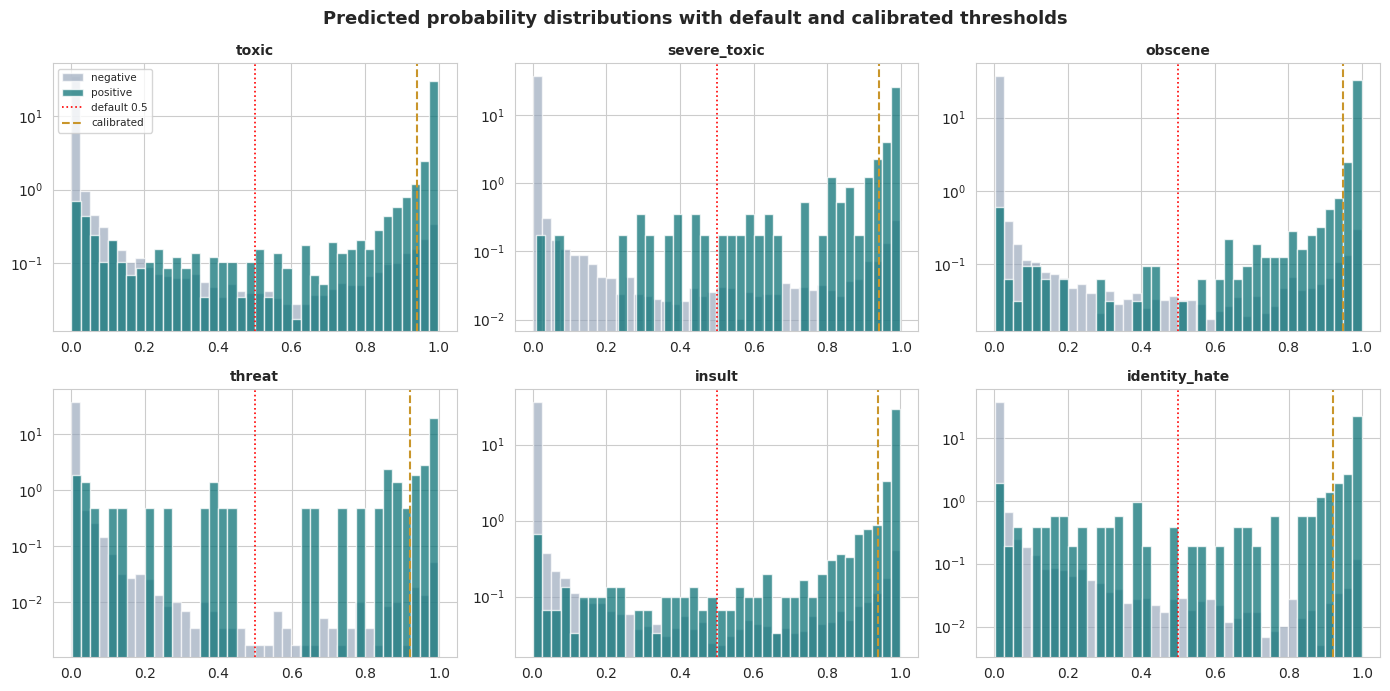

The separation between the two distributions explains the high ROC AUC; the position of
the calibrated threshold relative to 0.5 explains the F1 gain reported in Section 3.


In [12]:
# Predicted probability distributions: positive vs negative instances
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for i, (Lb, ax_) in enumerate(zip(LABELS, axes.ravel())):
    pos = test_prob[Y_test[:, i] == 1, i]
    neg = test_prob[Y_test[:, i] == 0, i]
    ax_.hist(neg, bins=40, alpha=.65, label="negative", color="#94A3B8", density=True)
    ax_.hist(pos, bins=40, alpha=.75, label="positive", color="#0D7377", density=True)
    ax_.axvline(0.5, color="red", ls=":", lw=1.2, label="default 0.5")
    ax_.axvline(best_thr[Lb], color="#C9962B", ls="--", lw=1.5, label="calibrated")
    ax_.set_title(f"{Lb}", fontweight="bold", fontsize=10)
    ax_.set_yscale("log")
    if i == 0: ax_.legend(fontsize=7.5)
plt.suptitle("Predicted probability distributions with default and calibrated thresholds",
             fontweight="bold", fontsize=13)
plt.tight_layout(); plt.savefig("/kaggle/working/fig_probability_distributions.png", dpi=200); plt.show()
print("The separation between the two distributions explains the high ROC AUC; the position of")
print("the calibrated threshold relative to 0.5 explains the F1 gain reported in Section 3.")


In [13]:
import glob
print("Figures written to /kaggle/working/ — download these for the report:")
for f in sorted(glob.glob("/kaggle/working/*.png")):
    print("  ", f.split("/")[-1])
print("\nCSV / JSON outputs:")
for f in sorted(glob.glob("/kaggle/working/*.csv")) + sorted(glob.glob("/kaggle/working/*.json")):
    print("  ", f.split("/")[-1])
print("\n>>> Click 'Save Version' now. <<<")


Figures written to /kaggle/working/ — download these for the report:
   fig_attention_tokens.png
   fig_confusion_matrices.png
   fig_probability_distributions.png
   fig_roc_pr_curves.png
   fig_threshold_tuning.png

CSV / JSON outputs:
   threshold_results.csv
   best_thresholds.json

>>> Click 'Save Version' now. <<<


## 5 · Summary

**Threshold optimisation** — Section 3 reports per-label F1 before and after tuning. Thresholds were
fitted on validation data only. This addresses the divergence between high ROC AUC and low fixed-
threshold F1 identified in Notebook 2.

**Interpretability** — Section 4 shows which tokens the model attends to. Report both what this
reveals about learned features and the limitation that attention is not a causal explanation.

Files written to `/kaggle/working/`: `best_thresholds.json`, `threshold_results.csv`,
`fig_threshold_tuning.png`, `fig_attention_tokens.png`. **Click Save Version.**
